# Import Library & Set Globals

In [1]:
%load_ext jupyter_black

# base
import os
import sys
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as p9

# single cell
import scanpy as sc
import decoupler as dc
import gseapy as gp

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.simplefilter("ignore", UserWarning)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.


In [2]:
%matplotlib inline
study = "paper_processed_FULL"

CORES = 30
DATADIR = "../../../data"
REFDIR = "../../../references"
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]

# Recombine with subcluster assignments

In [20]:
# load original object
annotation = "manDoublet-seuratV3-harmony-annotated"
savedir = os.path.join(DATADIR, "processed", "single cell", "3_annotated")
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

# load subsets
savedir = os.path.join(DATADIR, "processed", "single cell", "4_subclustered")
objs = ["macro", "fibro", "adipo", "stromal"]
adatas = [
    sc.read_h5ad(os.path.join(savedir, f"{annotation}-{celltype}.h5ad"))
    for celltype in tqdm(objs)
]

100%|██████████| 4/4 [01:25<00:00, 21.32s/it]


In [ ]:
# add new column & transfer non-subsetted groups
adata.obs["cell_type_hires"] = None
other_immune = adata.obs["cell_type"].isin(
    ["T Cell", "B Cell", "Dendritic Cell", "Mast Cell"]
)
adata.obs.loc[other_immune, "cell_type_hires"] = adata.obs["cell_type"]
# add hires subtypes
for ad in adatas:
    ad.obs["cell_type_hires"] = ad.obs.iloc[:, ad.obs.columns.str.contains("FINAL")]
merged = sc.concat(adatas)
adata.obs["cell_type_hires"][merged.obs.index] = merged.obs["cell_type_hires"]


In [31]:
# drop others & clean object
adata_clean = adata[~pd.isna(adata.obs["cell_type_hires"])]
clear_uns(adata_clean, "color")
clear_obsm(adata_clean, "ulm")

# save
print("begin saving...")
annotation = "annotated"
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
adata_clean.write(os.path.join(savedir, f"{annotation}.h5ad"))

begin saving...


# Run C2C Communication

### Run c2c

In [32]:
adata_by_cond = {}

annotation = "annotated"
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
adata_clean = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

# ligand-receptor pairs
cell_group = "cell_type"
cell2cell_interactions(adata_clean, cell_group, cores=CORES)
cell_group = "cell_type_hires"
cell2cell_interactions(adata_clean, cell_group, key="ccc_hires", cores=CORES)

# save ccc CSVs
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
adata_clean.uns["ccc_hires_filtered"].to_csv(
    os.path.join(savedir, "ccc_hires_filtered.csv")
)
adata_clean.uns["ccc_filtered"].to_csv(os.path.join(savedir, "ccc_lowres_filtered.csv"))

# save
annotation = "annotated-ccc"
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
adata_clean.write(os.path.join(savedir, f"{annotation}.h5ad"))

adata_by_cond["ALL"] = adata_clean

for cond in adata_clean.obs["Condition"].cat.categories.to_list():
    tmp = adata_clean[adata_clean.obs["Condition"] == cond]
    cell_group = "cell_type"
    cell2cell_interactions(tmp, cell_group, cores=CORES)
    cell_group = "cell_type_hires"
    cell2cell_interactions(tmp, cell_group, key="ccc_hires", cores=CORES)
    adata_by_cond[cond] = tmp

    # save
    annotation = f"annotated-ccc_{cond}"
    savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
    adata_by_cond[cond].write(os.path.join(savedir, f"{annotation}.h5ad"))

Processing mouseconsensus: 100%|██████████| 18/18 [00:18<00:00,  1.02s/it] 


found lowercase letters in first cell 'Dll1' of 'mouseconsensus', not converting!
Using provided `resource`.
Generating ligand-receptor stats for 51860 samples and 1754 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


  6%|▌         | 57/1000 [00:00<00:03, 250.77it/s]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. S

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


Processing mouseconsensus: 100%|██████████| 18/18 [00:16<00:00,  1.11it/s] 


...

Processing mouseconsensus: 100%|██████████| 18/18 [00:15<00:00,  1.13it/s] 


found lowercase letters in first cell 'Dll1' of 'mouseconsensus', not converting!
Using provided `resource`.


Generating ligand-receptor stats for 26953 samples and 1734 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:07<00:00, 141.85it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


### Plot

In [3]:
# load
adata_by_cond = {}
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")

for cond in ["LFD", "HFD"]:
    annotation = f"annotated-ccc_{cond}"
    adata_by_cond[cond] = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

annotation = f"annotated-ccc"
adata_by_cond["ALL"] = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

R_preload()

Attaching package: ‘dplyr’

  

    filter, lag

  

    intersect, setdiff, setequal, union

  
  
  
  
  
  
Attaching package: ‘matrixStats’

  

    count

  
Attaching package: ‘MatrixGenerics’

  

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, rowRanks,
    rowSdDiff


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Attaching package: ‘Seurat’

  

    Assays

  
  
Attaching package: ‘terra’

  

    distance, nearest, shift, trim, values, values<-, width

  

    distance, gaps, nearest, shift, trim, values, values<-, width

  

    distance, gaps, nearest, shift, trim, width

  

    values, values<-, width

  

    width

  


`adata_clean.obs["cell_type_hires"].cat.categories` yields the following categories:
* 'adipo:stressed adipocytes (AD6, B2m+)'
* 'adipo:stressed adipocytes (A5, Cfd+)'
* 'adipo:pre-browning (AD3, Mageb18+)'
* 'adipo:stem-like (AD4, Cacna1e+)'
* 'adipo:mature adipo (AD1/2)'
* 'fibro:Dpp4+/Pi16+ (APC1/2)'
* 'fibro:Dpp4+/Pi16+ (APC1/2, IFN-resp & SAT)'
* 'fibro:collagen-producing APCs (APC3, Lpl+)'
* 'fibro:secretory, TGFβ-resp (APC4, Lpl+)'
* 'endo:angiogenic'
* 'endo:arterial'
* 'endo:venous_lymphatic',
* 'endo:capillary'
* 'macro:RegMs (MC7) Arg1+'
* 'macro:???'
* 'macro:LAMs (MC3)'
* 'macro:MO-derived (MC4)',
* 'macro:MO-derived (MC5)'
* 'macro:MO-derived VAMs (MC2)',
* 'macro:VAMs (MC1)'
* 'macro:VAMs (MC2)',
* 'meso:ker19+'
* 'meso:pi16+',
* 'pcsmc:pcsmc'

In [ ]:
with ro.conversion.localconverter(get_converter()):
    ro.r(
        """
        library(CCPlotR)
        library(circlize)
        library(Polychrome)
        data(glasbey)
    """
    )

    for key in adata_by_cond:
        plot_df = adata_by_cond[key].uns["ccc_hires_filtered"].copy()
        plot_df["score"] = -np.log10(plot_df["magnitude_rank"])
        ro.globalenv["plot_df"] = plot_df
        ro.globalenv["condition"] = key
        ro.r(
            """
        png(paste0("ccc_plots/ccc_hires_",condition,".png"), width=20, height=20, units="in", res=300)
        cc_circos(
            plot_df,
            palette=paste0(glasbey, "FF")[-1],
            link.sort = TRUE,
            symmetric=TRUE,
            target.prop.height = 8,
            track_height = 10
        )
        dev.off()
        """
        )

        plot_df = adata_by_cond[key].uns["ccc_filtered"].copy()
        plot_df["score"] = -np.log10(plot_df["magnitude_rank"])
        ro.globalenv["plot_df"] = plot_df
        ro.globalenv["condition"] = key
        ro.r(
            """
        png(paste0("ccc_plots/ccc_lores_",condition,".png"), width=10, height=10, units="in", res=300)
        cc_circos(
            plot_df,
            palette=paste0(glasbey, "FF")[-1],
            link.sort = TRUE,
            symmetric=TRUE,
            target.prop.height = 8,
            track_height = 10
        )
        dev.off()
        """
        )

In [ ]:
with ro.conversion.localconverter(get_converter()):
    ro.r(
        """
        library(CCPlotR)
        library(Polychrome)
        data(glasbey)
    """
    )

    # for key in adata_by_cond:
    plot_df = adata_by_cond["ALL"].uns["ccc_hires_filtered"].copy()
    plot_df["score"] = -np.log10(plot_df["magnitude_rank"])
    celltypes_interest = [
        "MC3",
        "MC1",
        "MC7",
        "Dpp4+",
        "Lpl+",
    ]

    for query in celltypes_interest:
        tmp_df = plot_df[
            (
                plot_df["target"].str.contains(query, regex=False)
                | plot_df["source"].str.contains(query, regex=False)
            )
        ]
        ro.globalenv["plot_df"] = tmp_df
        ro.globalenv["condition"] = query

        ro.r(
            """
            png(paste0("ccc_plots/ccc_ALL_",condition,".png"), width=20, height=20, units="in", res=300)
            p <- cc_network(
                plot_df,
                colours=paste0(glasbey, "FF")[-1],
                layout = "fr"
            )
            print(p)
            dev.off()
        """
        )

In [57]:
from pycirclize import Circos

# Create matrix dataframe (3 x 6)
row_names = ["F1", "F2", "F3"]
col_names = ["T1", "T2", "T3", "T4", "T5", "T6"]
matrix_data = [
    [10, 16, 7, 7, 10, 8],
    [4, 9, 10, 12, 12, 7],
    [17, 13, 7, 4, 20, 4],
]
matrix_df = pd.DataFrame(matrix_data, index=row_names, columns=col_names)

# Initialize Circos instance for chord diagram plot
circos = Circos.chord_diagram(
    matrix_df,
    space=5,
    cmap="tab10",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1),
)

circos.savefig("example03.png")

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/liana/plotting/_common.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/liana/plotting/_common.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


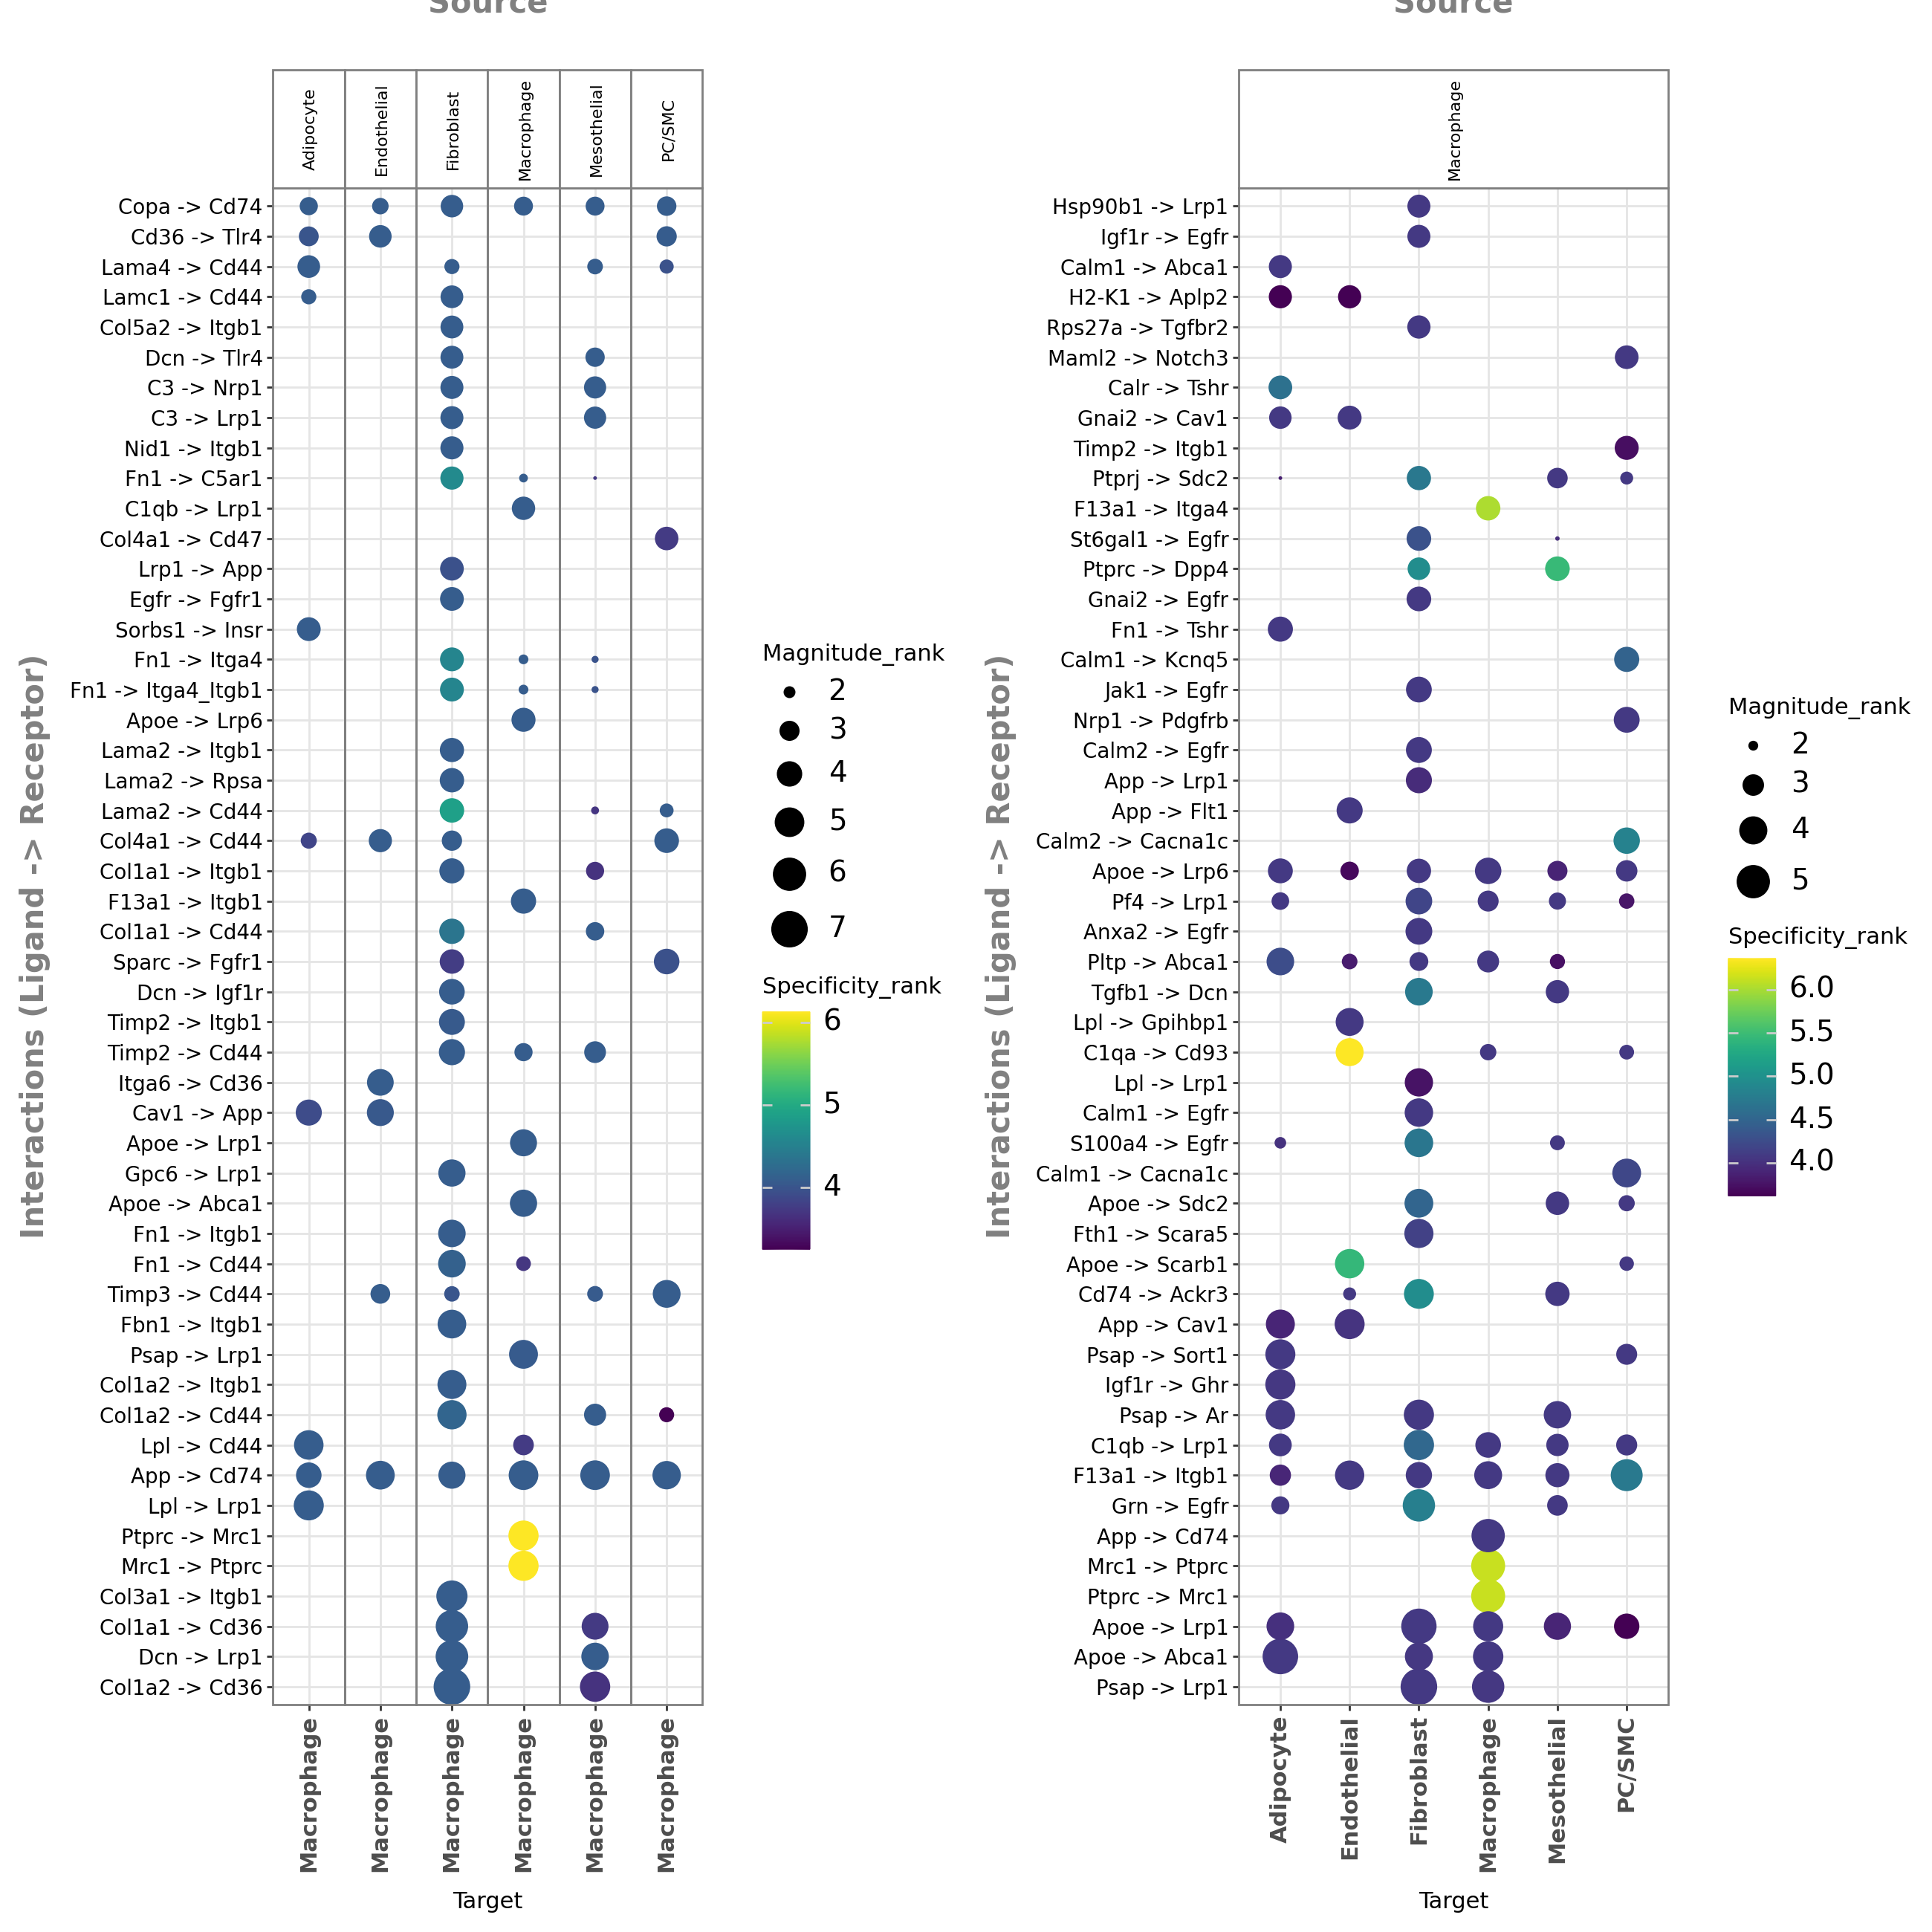

In [47]:
ccc_key = "ccc_filtered"
target_cells = ["Macrophage"]
source_cells = adata_clean.obs["cell_type"].cat.categories.copy().drop(target_cells)

p1 = li.pl.dotplot(
    adata_clean,
    uns_key=ccc_key,
    colour="specificity_rank",
    size="magnitude_rank",
    inverse_colour=True,
    inverse_size=True,
    # source_labels=target_cells,
    target_labels=target_cells,
    orderby="magnitude_rank",
    orderby_ascending=True,
    orderby_absolute=False,
    top_n=50,
    size_range=(0, 9),
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
) + p9.theme(strip_text=p9.element_text(size=8, angle=90))

p2 = li.pl.dotplot(
    adata_clean,
    uns_key=ccc_key,
    colour="specificity_rank",
    size="magnitude_rank",
    inverse_colour=True,
    inverse_size=True,
    source_labels=target_cells,
    # target_labels=target_cells,
    orderby="magnitude_rank",
    orderby_ascending=True,
    orderby_absolute=False,
    top_n=50,
    size_range=(0, 9),
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
) + p9.theme(strip_text=p9.element_text(size=8, angle=90))

p1 += p9.theme(figure_size=(13, 13), panel_spacing_x=0)
p2 += p9.theme(figure_size=(13, 13))

p1 | p2

In [129]:
plot_df = adata_by_cond["ALL"].uns["ccc_filtered"].copy()
query = "Tgfbr2"
tmp_df = plot_df[
    (
        plot_df["receptor"].str.contains(query, regex=False)
        | plot_df["ligand"].str.contains(query, regex=False)
    )
]
tmp_df

Loading ITables v2.4.4 from the internet... (need help?)


In [ ]:
plot_df = adata_by_cond["ALL"].uns["ccc_filtered"].copy()
genes_interest = [
    "Fn1",
    "Cd5l",
    "Col1a2",
    "Col3a1",
    "Col6a3",
    "Tgfbr1",
    "Tgfbr2",
    "Ifngr1",
    "Ifnar1",
    "Il1rl1",
    "Il1rn",
    "Lyve1",
    "Cd44",
    "Cx3cr1",
    "Dpp4",
]

plots = {}

for query in genes_interest:
    tmp_df = plot_df[
        (
            plot_df["receptor"].str.contains(query, regex=False)
            | plot_df["ligand"].str.contains(query, regex=False)
        )
    ]

    plots[query] = li.pl.dotplot(
        liana_res=tmp_df,
        colour="specificity_rank",
        size="magnitude_rank",
        inverse_colour=True,
        inverse_size=True,
        orderby="magnitude_rank",
        orderby_ascending=True,
        orderby_absolute=False,
        top_n=500,
        size_range=(0, 9),
        filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    ) + p9.theme(strip_text=p9.element_text(size=8, angle=90))

    plots[query] += p9.theme(figure_size=(25, 13), panel_spacing_x=0)

In [131]:
plots[genes_interest[0]]

for query in genes_interest:
    try:
        p9.ggsave(
            plots[query],
            filename=f"gene_{query}.png",
            width=25,  # A width larger than the default limit
            height=13,  # A height larger than the default limit
            dpi=300,
            limitsize=False,
        )
    except:
        pass

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/liana/plotting/_common.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/liana/plotting/_common.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


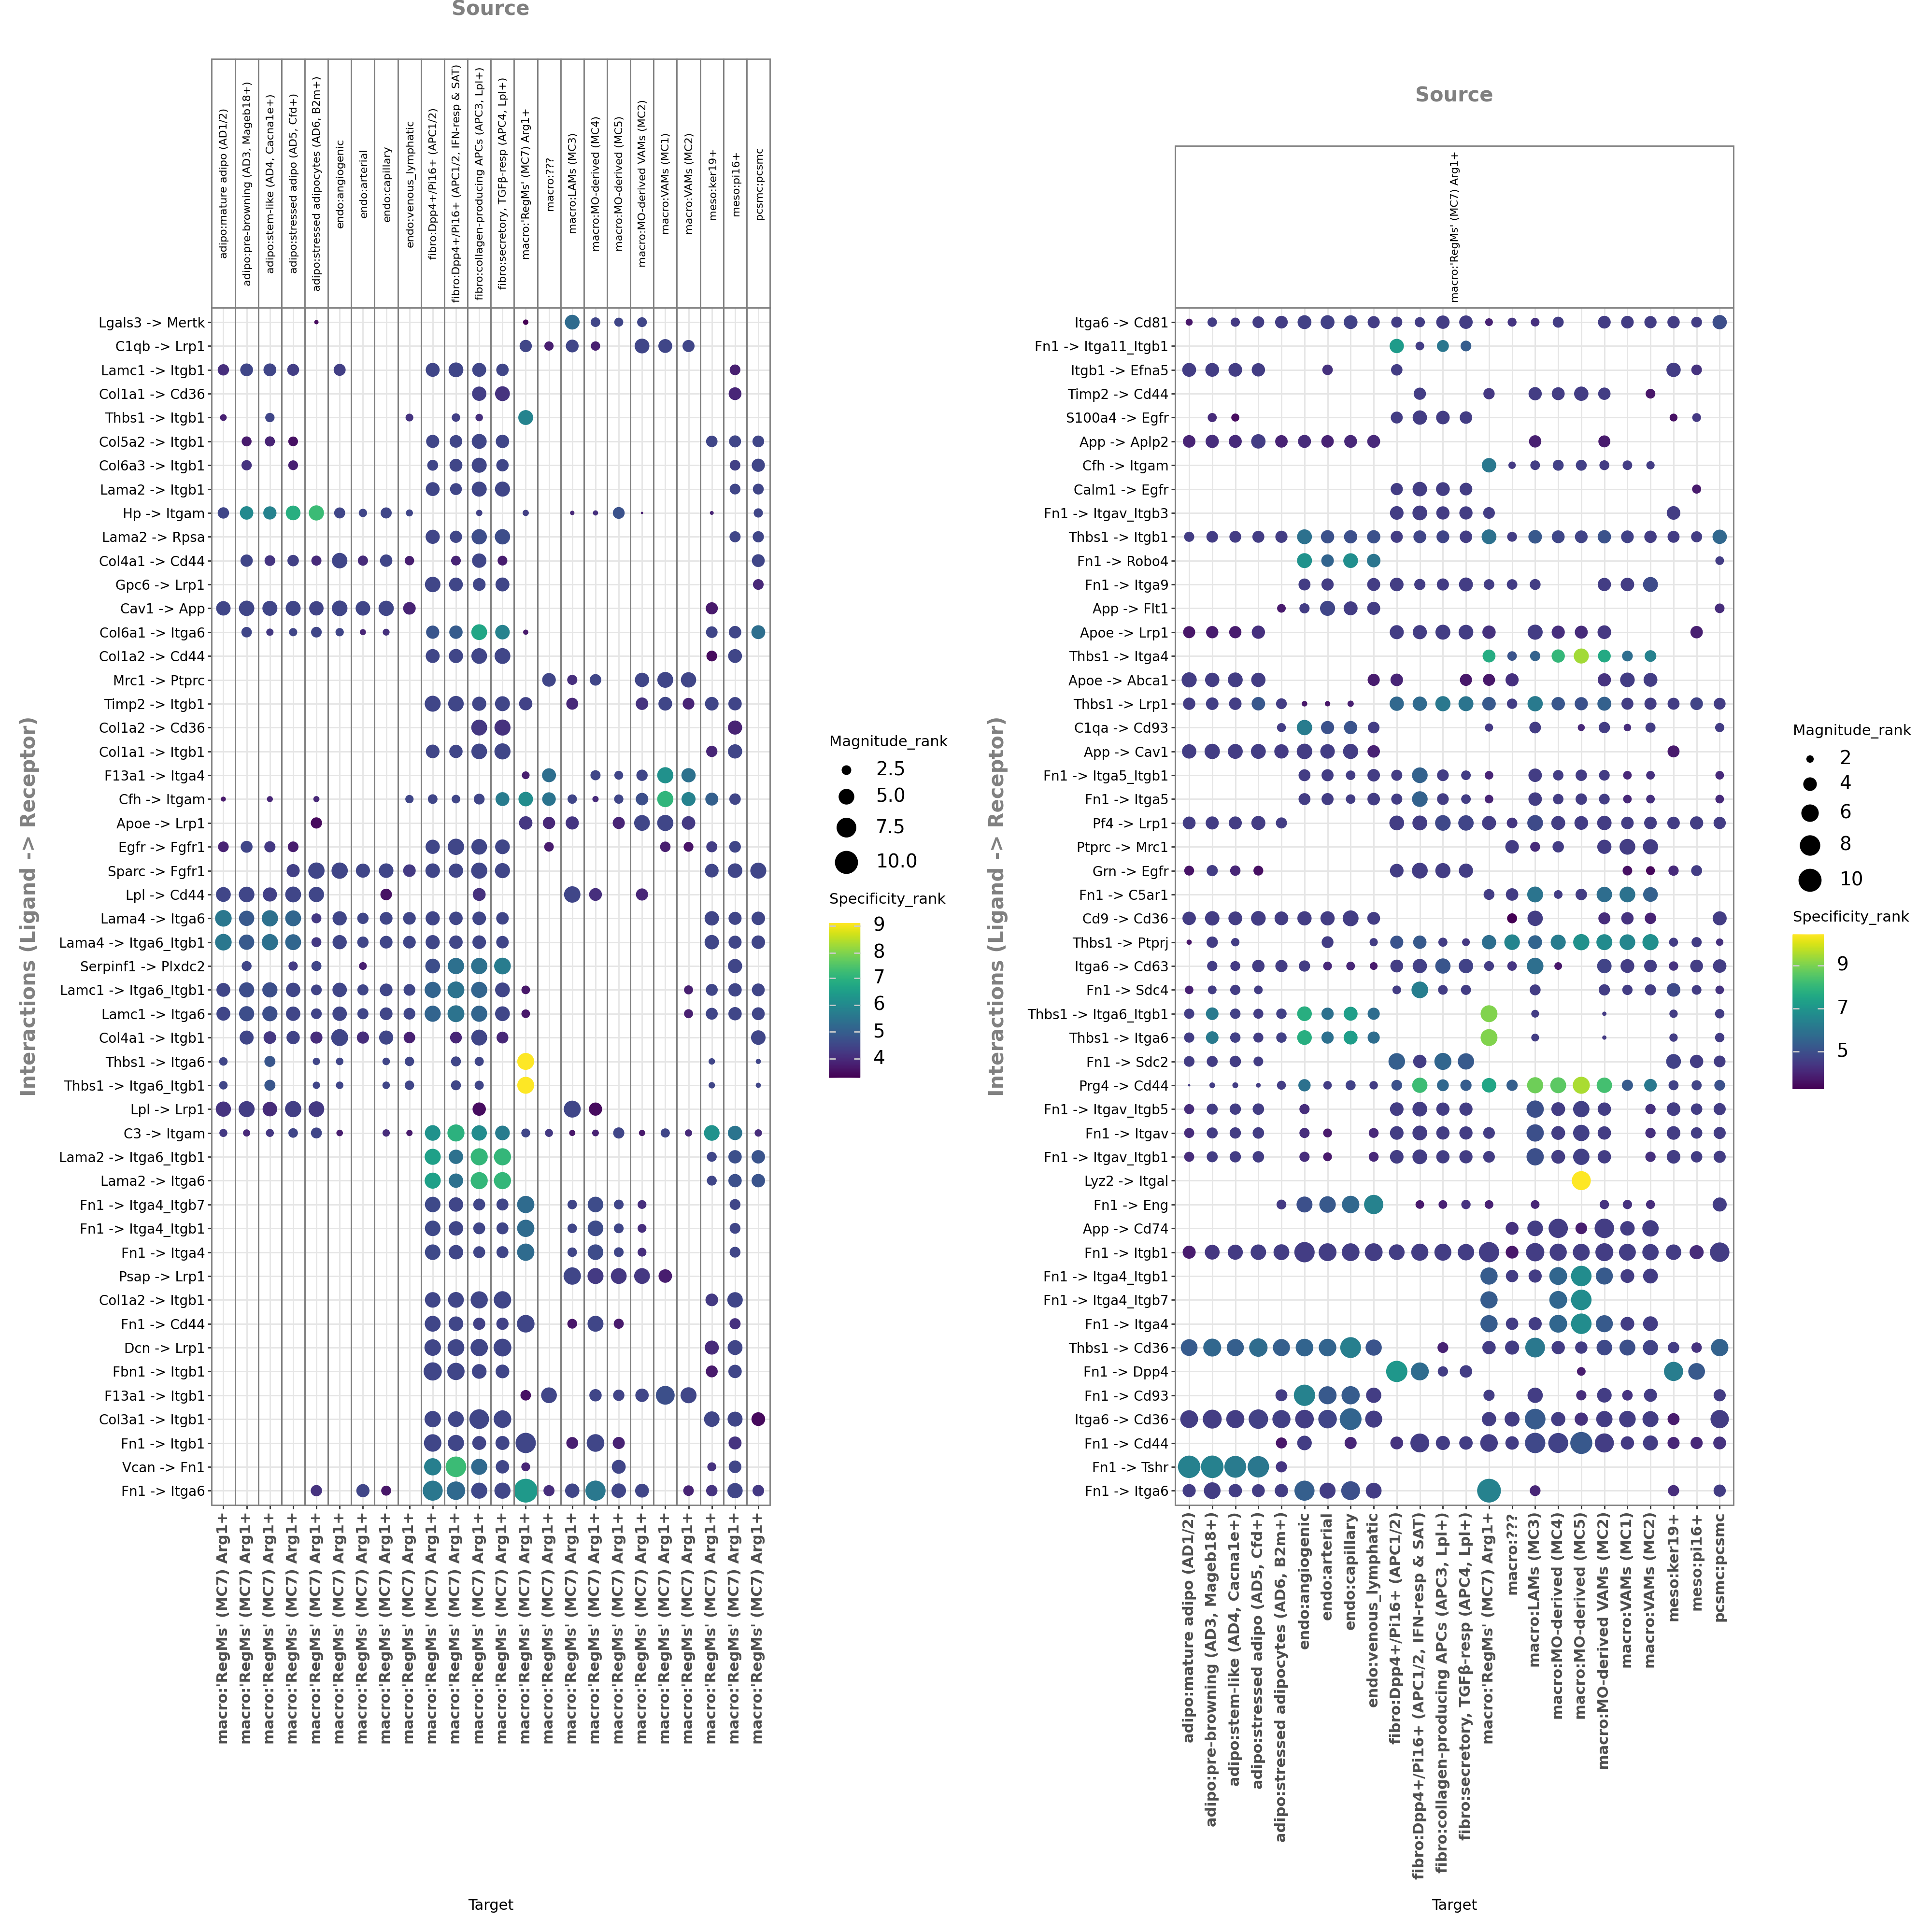

In [48]:
ccc_key = "ccc_hires_filtered"
target_cells = ["macro:'RegMs' (MC7) Arg1+"]
source_cells = (
    adata_clean.obs["cell_type_hires"].cat.categories.copy().drop(target_cells)
)

p1 = li.pl.dotplot(
    adata_clean,
    uns_key=ccc_key,
    colour="specificity_rank",
    size="magnitude_rank",
    inverse_colour=True,
    inverse_size=True,
    # source_labels=target_cells,
    target_labels=target_cells,
    orderby="magnitude_rank",
    orderby_ascending=True,
    orderby_absolute=False,
    top_n=50,
    size_range=(0, 9),
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
) + p9.theme(strip_text=p9.element_text(size=8, angle=90))

p2 = li.pl.dotplot(
    adata_clean,
    uns_key=ccc_key,
    colour="specificity_rank",
    size="magnitude_rank",
    inverse_colour=True,
    inverse_size=True,
    source_labels=target_cells,
    # target_labels=target_cells,
    orderby="magnitude_rank",
    orderby_ascending=True,
    orderby_absolute=False,
    top_n=50,
    size_range=(0, 9),
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
) + p9.theme(strip_text=p9.element_text(size=8, angle=90))

p1 += p9.theme(figure_size=(20, 20), panel_spacing_x=0)
p2 += p9.theme(figure_size=(20, 20))

p1 | p2

In [ ]:
## PLOTS THAT DONT WORK >:(

# source_cells = ["Adipocyte", "Fibroblast", "Mesothelial", "Endothelial", "PC/SMC"]

# li.pl.circle_plot(
#     adata_clean,
#     uns_key="ccc",
#     groupby="cell_type",
#     score_key="magnitude_rank",
#     inverse_score=True,
#     # source_labels="Adipocyte",
#     filter_fun=lambda x: x["specificity_rank"] <= 0.05,
#     pivot_mode="counts",
# )

# source_cells = ["Adipocyte", "Fibroblast", "Mesothelial", "Endothelial", "PC/SMC"]
# target_cells = ["Macrophage"]
# li.pl.tileplot(
#     adata=adata_clean,
#     # NOTE: fill & label need to exist for both
#     # ligand_ and receptor_ columns
#     fill="magnitude_rank",
#     label="magnitude_rank",
#     label_fun=lambda x: float(f"{x:.2E}"),
#     filter_fun=lambda x: x["specificity_rank"] <= 0.05,
#     top_n=10,
#     orderby="magnitude_rank",
#     orderby_ascending=True,
#     source_labels=source_cells,
#     target_labels=source_cells,
#     uns_key="ccc",
#     source_title="Ligand",
#     target_title="Receptor",
#     figure_size=(12, 7),
# )

# Save/Load

In [ ]:
# save
annotation = "annotated-ccc"
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
adata_clean.write(os.path.join(savedir, f"{annotation}.h5ad"))

In [ ]:
# load
annotation = "annotated-ccc"
savedir = os.path.join(DATADIR, "processed", "single cell", "5_analysis")
adata_clean = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

### Create RDS object

In [ ]:
tmp = adata_clean.copy()
del tmp.uns

AnnData object with n_obs × n_vars = 49129 × 21205
    obs: 'Identifier', 'Groups', 'Experiment', 'Condition', 'Sample Type', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet', 'leiden_doublets', 'manual_doublet', 'leiden', 'cell_type', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'cell_type_hires'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Condition_colors', 'Groups_colors', 'Sample Type_colors', 'ccc', 'ccc_filtered', '

In [ ]:
with ro.conversion.localconverter(get_converter()):
    ro.globalenv[""]

In [ ]:
R_preload()

%Rpush 
%R counts(sce) <- assay(sce, "X")
%R seurat.obj <- as.Seurat(sce,data = NULL)
%R seurat.obj <- RenameAssays(seurat.obj,"originalexp","RNA")
%R print(seurat.obj)

RParsingError: Parsing status not OK - PARSING_STATUS.PARSE_ERROR

In [ ]:
%%R
savedir <- here("data", "processed", "single cell", "3_annotated", "manDoublet-seuratV3-harmony-annotated.rds")
saveRDS(object=seurat.obj, file=savedir)